# Logistic Regression

Imports and helpers

In [1]:
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 20000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 20000)
y_valid shape: (20000,)


In [5]:
X_test = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 20000)
y_test shape: (20000,)


## Model Training

model setup and random search 

In [6]:
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_params = {
    'C': uniform(0.01, 20.0),
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

Initialize RandomizedSearchCV (3-fold cross-validation acts as our validation set)

In [ ]:
lr_search = RandomizedSearchCV(lr_model, lr_params, 
                               n_iter=50, cv=5, scoring='accuracy', 
                               random_state=42, n_jobs=-1, verbose=1)

In [8]:
print("Training Logistic Regression...")
start_time = time.time()
# Fit expects a 1D y array/series
lr_search.fit(X_train, y_train)
lr_train_time = time.time() - start_time
print(f"Completed in {lr_train_time:.2f}s. Best params: {lr_search.best_params_}")

Training Logistic Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


Completed in 239.27s. Best params: {'C': np.float64(2.8284844994952527), 'class_weight': None, 'solver': 'liblinear'}


Extract best models

In [9]:
best_lr = lr_search.best_estimator_
best_lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(2.8284844994952527)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of 

In [10]:
print(f"Best LR Params: {lr_search.best_params_}")

Best LR Params: {'C': np.float64(2.8284844994952527), 'class_weight': None, 'solver': 'liblinear'}


## Model Evaluation

Predict on the unseen Test set

In [11]:
lr_preds = best_lr.predict(X_test)

performance

In [12]:
print(f"Training Time: {lr_train_time:.4f} seconds")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

Training Time: 239.2740 seconds
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      9966
    Positive       0.86      0.87      0.86     10034

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



confusion matrices

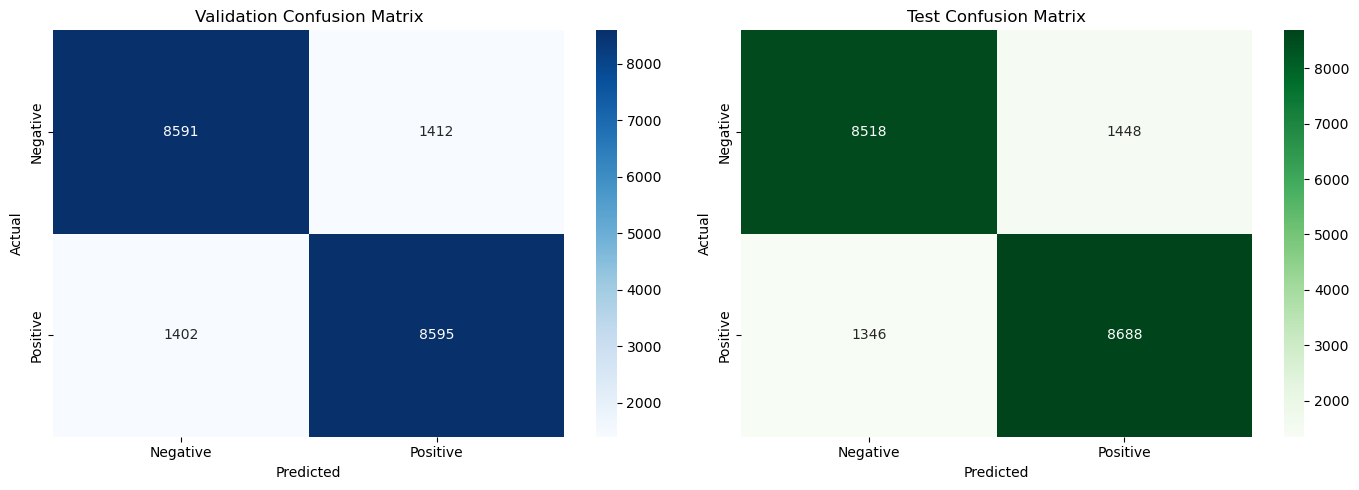

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ensure 1D truth arrays
y_test_true = y_test.squeeze() if hasattr(y_test, 'squeeze') else y_test
y_valid_true = y_valid.squeeze() if hasattr(y_valid, 'squeeze') else y_valid

# predictions
y_valid_pred = best_lr.predict(X_valid)
y_test_pred = lr_preds if 'lr_preds' in globals() else best_lr.predict(X_test)

labels = [1, 2]
ticklabels = ['Negative', 'Positive']

cm_val = confusion_matrix(y_valid_true, y_valid_pred, labels=labels)
cm_test = confusion_matrix(y_test_true, y_test_pred, labels=labels)

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Model Testing

In [18]:
try:
    import joblib
except Exception:
    joblib = None

vec_path = Path('data/vectorizers/tfidf_vectorizer.joblib')
vectorizer = None
if joblib is not None and vec_path.exists():
    try:
        vectorizer = joblib.load(vec_path)
    except Exception:
        vectorizer = None

if vectorizer is not None and hasattr(best_lr, 'coef_'):
    feature_names = (vectorizer.get_feature_names_out()
                     if hasattr(vectorizer, 'get_feature_names_out')
                     else vectorizer.get_feature_names())
    coefs = best_lr.coef_.ravel()
    top_pos_idx = coefs.argsort()[::-1][:20]
    top_neg_idx = coefs.argsort()[:20]

    print('Top positive features:')
    for i in top_pos_idx:
        print(f'{feature_names[i]}\t{coefs[i]:.4f}')

    print('\nTop negative features:')
    for i in top_neg_idx:
        print(f'{feature_names[i]}\t{coefs[i]:.4f}')
else:
    print('Vectorizer not found or model has no coef_. Save vectorizer to data/vectorizers/tfidf_vectorizer.joblib to enable feature inspection.')

Top positive features:
great	11.0086
excellent	10.5998
perfect	8.1229
love	7.8413
wonderful	7.6949
best	7.6224
awesome	7.5230
easy	7.1280
pleased	7.0395
amazing	6.7310
complaint	6.6780
fantastic	6.5158
favorite	6.4083
outstanding	6.2819
enjoyed	6.1082
highly recommend	6.1019
perfectly	6.0253
highly	5.9098
satisfied	5.6756
fascinating	5.2541

Top negative features:
worst	-12.4077
boring	-10.9568
disappointing	-10.6813
disappointed	-10.2909
waste	-9.7771
disappointment	-9.4518
poorly	-9.4397
terrible	-9.1654
poor	-9.0787
returned	-8.9435
awful	-8.1629
horrible	-7.8767
unfortunately	-7.6641
worthless	-7.0332
useless	-6.9335
sadly	-6.6017
mediocre	-6.4971
refund	-6.4772
garbage	-6.4223
waste money	-6.3466


In [19]:
# Evaluate best_lr on the validation and test sets
y_val = y_valid if not (hasattr(y_valid, 'columns') and 'review_target' in y_valid.columns) else y_valid['review_target'].squeeze()
y_test_true = y_test if not (hasattr(y_test, 'columns') and 'review_target' in y_test.columns) else y_test['review_target'].squeeze()

print('Validation set performance:')
y_val_pred = best_lr.predict(X_valid)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(classification_report(y_val, y_val_pred, target_names=['Negative', 'Positive']))
print('Confusion matrix (validation):', confusion_matrix(y_val, y_val_pred))
print('Confusion matrix (test):', confusion_matrix(y_test_true, y_test_pred))
print(classification_report(y_test_true, y_test_pred, target_names=['Negative', 'Positive']))
print(f"Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}")
y_test_pred = best_lr.predict(X_test)
print('Test set performance:')
print('Confusion matrix (test):', confusion_matrix(y_test_true, y_test_pred))

Validation set performance:
Accuracy: 0.8593
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86     10003
    Positive       0.86      0.86      0.86      9997

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000

Confusion matrix (validation): [[8591 1412]
 [1402 8595]]
Confusion matrix (test): [[8518 1448]
 [1346 8688]]
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      9966
    Positive       0.86      0.87      0.86     10034

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000

Accuracy: 0.8603
Test set performance:
Confusion matrix (test): [[8518 1448]
 [1346 8688]]


## Saving the Model and Pipeline

## Insights